In [32]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [14]:
df = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
print(df.head())


C:\Users\rohit\AppData\Local\Temp\ipykernel_9504\3461197969.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("AAPL", start="2022-01-01", end="2024-12-31")
[*********************100%***********************]  1 of 1 completed

Price            Close        High         Low        Open     Volume
Ticker            AAPL        AAPL        AAPL        AAPL       AAPL
Date                                                                 
2022-01-03  178.270325  179.122459  174.058687  174.176216  104487900
2022-01-04  176.007797  179.181232  175.439712  178.877604   99310400
2022-01-05  171.326004  176.468135  171.051758  175.919643   94537600
2022-01-06  168.466019  171.698219  168.113415  169.151633   96904000
2022-01-07  168.632492  170.562016  167.515916  169.337700   86709100


In [15]:
df.columns = df.columns.get_level_values(0)
df.head()

Price,Close,High,Low,Open,Volume
Date,,,,,
2022-01-03,178.270325,179.122459,174.058687,174.176216,104487900
2022-01-04,176.007797,179.181232,175.439712,178.877604,99310400
2022-01-05,171.326004,176.468135,171.051758,175.919643,94537600
2022-01-06,168.466019,171.698219,168.113415,169.151633,96904000
2022-01-07,168.632492,170.562016,167.515916,169.337700,86709100


In [16]:
df = df.dropna()
df = df.reset_index()
df.head()

Price,Date,Close,High,Low,Open,Volume
0,2022-01-03,178.270325,179.122459,174.058687,174.176216,104487900
1,2022-01-04,176.007797,179.181232,175.439712,178.877604,99310400
2,2022-01-05,171.326004,176.468135,171.051758,175.919643,94537600
3,2022-01-06,168.466019,171.698219,168.113415,169.151633,96904000
4,2022-01-07,168.632492,170.562016,167.515916,169.337700,86709100


In [17]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')

In [18]:
df.columns.name = None
print(df.columns)
df.head()

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')


,Date,Close,High,Low,Open,Volume
0,2022-01-03,178.270325,179.122459,174.058687,174.176216,104487900
1,2022-01-04,176.007797,179.181232,175.439712,178.877604,99310400
2,2022-01-05,171.326004,176.468135,171.051758,175.919643,94537600
3,2022-01-06,168.466019,171.698219,168.113415,169.151633,96904000
4,2022-01-07,168.632492,170.562016,167.515916,169.337700,86709100


In [19]:
df["Date"] = pd.to_datetime(df["Date"])


In [24]:
price = df["Close"]
returns = price.diff().fillna(0)


In [26]:
pd.concat([df.head(), df.tail()])

,Date,Close,High,Low,Open,Volume
0,2022-01-03,178.270325,179.122459,174.058687,174.176216,104487900
1,2022-01-04,176.007797,179.181232,175.439712,178.877604,99310400
2,2022-01-05,171.326004,176.468135,171.051758,175.919643,94537600
3,2022-01-06,168.466019,171.698219,168.113415,169.151633,96904000
4,2022-01-07,168.632492,170.562016,167.515916,169.337700,86709100
747,2024-12-23,254.120667,254.498945,252.308854,253.622918,40858800
748,2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700
749,2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100
750,2024-12-27,254.439209,257.535222,251.920601,256.669114,42355300
751,2024-12-30,251.064499,252.358649,249.621030,251.094363,35557500


In [27]:
def gaussian_kernel(size, sigma):
    x = np.arange(-size, size + 1)
    kernel = np.exp(-(x ** 2) / (2 * sigma ** 2))
    return kernel / kernel.sum()


In [28]:
kernel = gaussian_kernel(size=10, sigma=3)


In [29]:
shaped_signal = np.convolve(returns, kernel, mode="same")


In [30]:
threshold = shaped_signal.std() * 1.5

buy_signal  = shaped_signal > threshold
sell_signal = shaped_signal < -threshold
df["Buy_Signal"]  = buy_signal
df["Sell_Signal"] = sell_signal
pd.concat([df.head(), df.tail()])

,Date,Close,High,Low,Open,Volume,Buy_Signal,Sell_Signal
0,2022-01-03,178.270325,179.122459,174.058687,174.176216,104487900,False,False
1,2022-01-04,176.007797,179.181232,175.439712,178.877604,99310400,False,False
2,2022-01-05,171.326004,176.468135,171.051758,175.919643,94537600,False,False
3,2022-01-06,168.466019,171.698219,168.113415,169.151633,96904000,False,False
4,2022-01-07,168.632492,170.562016,167.515916,169.337700,86709100,False,False
747,2024-12-23,254.120667,254.498945,252.308854,253.622918,40858800,False,False
748,2024-12-24,257.037506,257.047440,254.140589,254.339701,23234700,False,False
749,2024-12-26,257.853760,258.928914,256.470034,257.027510,27237100,False,False
750,2024-12-27,254.439209,257.535222,251.920601,256.669114,42355300,False,False
751,2024-12-30,251.064499,252.358649,249.621030,251.094363,35557500,False,False


In [34]:
df[(df['Buy_Signal'] == True) | (df['Sell_Signal'] == True)]


,Date,Close,High,Low,Open,Volume,Buy_Signal,Sell_Signal
10,2022-01-18,166.311188,168.994880,165.929202,167.986045,90956700,False,True
11,2022-01-19,162.814560,167.564916,162.530525,166.507104,94815000,False,True
12,2022-01-20,161.129898,166.193671,160.806677,163.549150,91420500,False,True
18,2022-01-28,166.830292,166.849885,159.455009,162.305222,179935700,True,False
19,2022-01-31,171.188889,171.404370,166.027164,166.663818,115541600,True,False
...,...,...,...,...,...,...,...,...
730,2024-11-27,233.872238,234.628826,232.757286,233.414318,33498400,True,False
731,2024-11-29,236.261459,236.739294,232.916587,233.752801,28481400,True,False
732,2024-12-02,238.511261,239.705855,236.092209,236.201715,48137100,True,False
733,2024-12-03,241.557495,241.667000,237.824379,238.730285,38861000,True,False


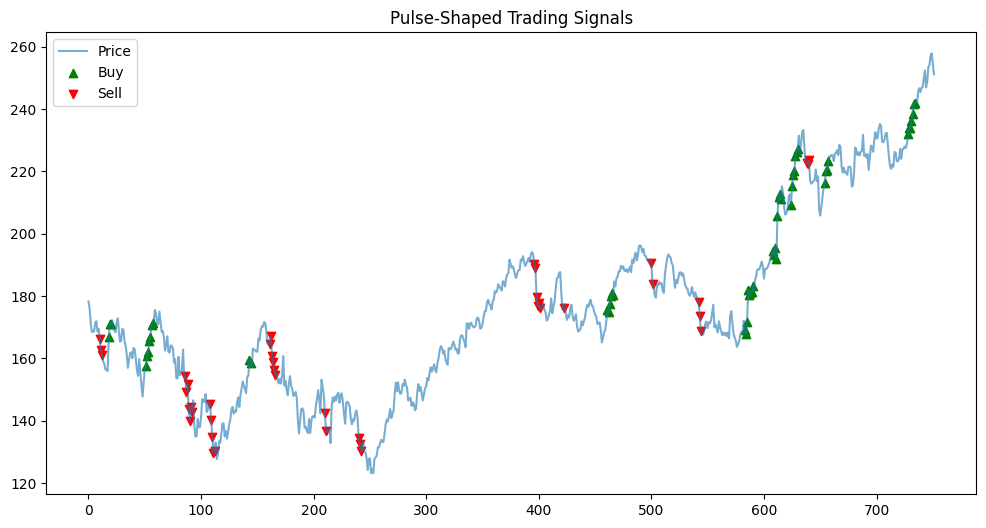

In [35]:
plt.figure(figsize=(12,6))
plt.plot(price, label="Price", alpha=0.6)

plt.scatter(df.index[buy_signal], price[buy_signal],
            marker="^", color="green", label="Buy")

plt.scatter(df.index[sell_signal], price[sell_signal],
            marker="v", color="red", label="Sell")

plt.legend()
plt.title("Pulse-Shaped Trading Signals")
plt.show()


Matched filter (pattern detection)

Detect a known breakout shape:
Trade when correlation peaks.

In [36]:
pattern = np.array([0, 0.2, 0.5, 1.0, 0.5, 0.2, 0])
matched_output = np.convolve(returns, pattern[::-1], mode="same")
